In [1]:
# =====================================================================
# CELL 1: ENVIRONMENT SETUP (LOGISTIC REGRESSION ABLATION)
# =====================================================================
!pip install sentencepiece transformers safetensors accelerate scikit-learn -q

import numpy as np
import matplotlib.pyplot as plt
import json
import re
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression

# Load Semantic Embedder for TVS calculation
embedder = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
print("SentenceTransformer loaded.")

from google.colab import drive
drive.mount('/content/drive')

# Global Configuration for Experiment
SEED_VALUES = [2, 3, 5] # The different seed values to test
NUM_RUNS = 5            # Number of times to run the split & training to get error bars

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SentenceTransformer loaded.
Mounted at /content/drive


In [2]:
# =====================================================================
# CELL 2: PRELOAD TRAJECTORIES
# =====================================================================
print(f"Loading Trajectories from Google Drive...")
dataset = np.load("/content/drive/MyDrive/llada/tvs_master_variance_arrays_extra.npz")
clean_traj = dataset['clean_traj']
conflict_traj = dataset['conflict_traj']

print("Loading Verified Master Dataset for base sentences...")
with open("/content/drive/MyDrive/llada/verified_master_dataset.json", "r") as f:
    verified_eval_facts = json.load(f)

NUM_FACTS = clean_traj.shape[0]

Loading Trajectories from Google Drive...
Loading Verified Master Dataset for base sentences...


In [4]:
# =====================================================================
# CELL 3: DYNAMIC SEED ABLATION & LR EVALUATION LOOP (1 CHANNEL)
# =====================================================================
results_summary = {}

for NUM_SEEDS_TO_USE in SEED_VALUES:
    print(f"\n{'='*70}")
    print(f"STARTING LR ABLATION FOR: {NUM_SEEDS_TO_USE} SEEDS (1 CHANNEL)")
    print(f"{'='*70}")

    # ---------------------------------------------------------
    # 1. FAST BATCHED VARIANCE RECALCULATION
    # ---------------------------------------------------------
    print(f"Recalculating Semantic Variance for {NUM_SEEDS_TO_USE} seeds...")
    clean_raw_k, conflict_raw_k = [], []

    for i in tqdm(range(NUM_FACTS), desc=f"Calculating Embeddings"):
        base_sentence = verified_eval_facts[i]["base"]

        c_traj_k = clean_traj[i, :NUM_SEEDS_TO_USE, :]
        conf_traj_k = conflict_traj[i, :NUM_SEEDS_TO_USE, :]
        K = c_traj_k.shape[0]

        c_flat = c_traj_k.T.flatten()
        conf_flat = conf_traj_k.T.flatten()

        all_texts = np.concatenate([c_flat, conf_flat])

        isolated_entities = []
        for text in all_texts:
            raw_answer = text.split(base_sentence)[-1] if base_sentence in text else text
            clean_answer = re.sub(r'[^a-zA-Z0-9\s]', '', raw_answer).strip().lower()
            isolated_entities.append(clean_answer if clean_answer else "[EMPTY_TOKEN]")

        embeddings = embedder.encode(isolated_entities, batch_size=200, show_progress_bar=False)

        c_vars, conf_vars = [], []

        for step in range(50):
            start_idx = step * K
            step_embs = embeddings[start_idx : start_idx + K]
            dist = 1 - cosine_similarity(step_embs)
            i_idx, j_idx = np.triu_indices(K, k=1)
            c_vars.append(np.clip(dist[i_idx, j_idx].mean(), 0, None))

        offset = 50 * K
        for step in range(50):
            start_idx = offset + (step * K)
            step_embs = embeddings[start_idx : start_idx + K]
            dist = 1 - cosine_similarity(step_embs)
            i_idx, j_idx = np.triu_indices(K, k=1)
            conf_vars.append(np.clip(dist[i_idx, j_idx].mean(), 0, None))

        clean_raw_k.append(c_vars)
        conflict_raw_k.append(conf_vars)

    clean_raw = np.array(clean_raw_k)
    conflict_raw = np.array(conflict_raw_k)

    # Convert to Numpy Arrays (1 Channel: Raw Variance Only)
    X_list, y_list = [], []
    for i in range(NUM_FACTS):
        X_list.append(np.expand_dims(clean_raw[i], axis=0))
        y_list.append(0)
        X_list.append(np.expand_dims(conflict_raw[i], axis=0))
        y_list.append(1)

    X = np.array(X_list)  # Shape: (Batch, 1, 50)
    y = np.array(y_list)  # Shape: (Batch,)

    # Flatten X for Logistic Regression: (Batch, 1, 50) -> (Batch, 50)
    X_flat = X.reshape(X.shape[0], -1)

    # ---------------------------------------------------------
    # 2. MULTIPLE TRAINING RUNS FOR ERROR BARS
    # ---------------------------------------------------------
    acc_list, auroc_list = [], []

    print(f"\nRunning Logistic Regression {NUM_RUNS} Times...")
    for run in range(NUM_RUNS):
        print(f"  -> Run {run+1}/{NUM_RUNS}", end="")

        # Varying the random_state ensures we get different splits each time
        X_train, X_temp, y_train, y_temp = train_test_split(X_flat, y, test_size=0.30, random_state=42+run, stratify=y)
        X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42+run, stratify=y_temp)

        # Initialize and train the Logistic Regression model
        lr_model = LogisticRegression(max_iter=2000, random_state=42)
        lr_model.fit(X_train, y_train)

        # Evaluate on Test Set (using the positive class index 1 for probabilities)
        test_probs = lr_model.predict_proba(X_test)[:, 1]
        test_preds = lr_model.predict(X_test)

        acc = accuracy_score(y_test, test_preds)
        auroc = roc_auc_score(y_test, test_probs)

        acc_list.append(acc * 100)
        auroc_list.append(auroc)
        print(f" | Test Acc: {acc * 100:.2f}% | Test AUROC: {auroc:.4f}")

    results_summary[NUM_SEEDS_TO_USE] = {
        "mean_acc": np.mean(acc_list), "std_acc": np.std(acc_list),
        "mean_auroc": np.mean(auroc_list), "std_auroc": np.std(auroc_list)
    }


STARTING LR ABLATION FOR: 2 SEEDS (1 CHANNEL)
Recalculating Semantic Variance for 2 seeds...


Calculating Embeddings: 100%|██████████| 2947/2947 [04:54<00:00, 10.01it/s]



Running Logistic Regression 5 Times...
  -> Run 1/5 | Test Acc: 69.94% | Test AUROC: 0.7590
  -> Run 2/5 | Test Acc: 71.07% | Test AUROC: 0.7843
  -> Run 3/5 | Test Acc: 70.40% | Test AUROC: 0.7711
  -> Run 4/5 | Test Acc: 71.75% | Test AUROC: 0.7760
  -> Run 5/5 | Test Acc: 70.62% | Test AUROC: 0.7723

STARTING LR ABLATION FOR: 3 SEEDS (1 CHANNEL)
Recalculating Semantic Variance for 3 seeds...


Calculating Embeddings: 100%|██████████| 2947/2947 [05:55<00:00,  8.30it/s]



Running Logistic Regression 5 Times...
  -> Run 1/5 | Test Acc: 69.83% | Test AUROC: 0.7659
  -> Run 2/5 | Test Acc: 71.64% | Test AUROC: 0.7919
  -> Run 3/5 | Test Acc: 72.77% | Test AUROC: 0.7802
  -> Run 4/5 | Test Acc: 72.66% | Test AUROC: 0.7839
  -> Run 5/5 | Test Acc: 71.86% | Test AUROC: 0.7813

STARTING LR ABLATION FOR: 5 SEEDS (1 CHANNEL)
Recalculating Semantic Variance for 5 seeds...


Calculating Embeddings: 100%|██████████| 2947/2947 [07:44<00:00,  6.35it/s]


Running Logistic Regression 5 Times...
  -> Run 1/5 | Test Acc: 69.60% | Test AUROC: 0.7763
  -> Run 2/5 | Test Acc: 72.09% | Test AUROC: 0.7976
  -> Run 3/5 | Test Acc: 72.09% | Test AUROC: 0.7806
  -> Run 4/5 | Test Acc: 71.86% | Test AUROC: 0.7885
  -> Run 5/5 | Test Acc: 70.51% | Test AUROC: 0.7824



FINAL RESULTS: LR - EFFECT OF NUMBER OF SEEDS
Seeds: 2
  Accuracy : 70.76% ± 0.62%
  AUROC    : 0.7725 ± 0.0082

Seeds: 3
  Accuracy : 71.75% ± 1.06%
  AUROC    : 0.7806 ± 0.0084

Seeds: 5
  Accuracy : 71.23% ± 1.00%
  AUROC    : 0.7851 ± 0.0074



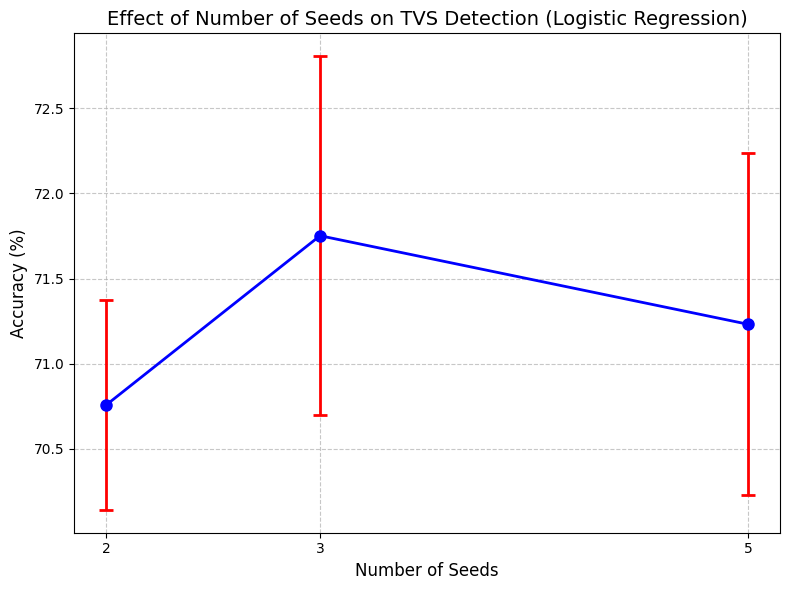

In [5]:
# =====================================================================
# CELL 4: FINAL REPORT AND ERROR BAR GRAPH (LR)
# =====================================================================
print("\n" + "="*50)
print("FINAL RESULTS: LR - EFFECT OF NUMBER OF SEEDS")
print("="*50)
for num_seeds, metrics in results_summary.items():
    print(f"Seeds: {num_seeds}")
    print(f"  Accuracy : {metrics['mean_acc']:.2f}% ± {metrics['std_acc']:.2f}%")
    print(f"  AUROC    : {metrics['mean_auroc']:.4f} ± {metrics['std_auroc']:.4f}\n")

# Prepare data for graphing
seeds = list(results_summary.keys())
mean_accs = [results_summary[s]['mean_acc'] for s in seeds]
std_accs = [results_summary[s]['std_acc'] for s in seeds]

# Plotting
plt.figure(figsize=(8, 6))
plt.errorbar(seeds, mean_accs, yerr=std_accs, fmt='-o', capsize=5, capthick=2, ecolor='red', color='blue', markersize=8, linewidth=2)
plt.title("Effect of Number of Seeds on TVS Detection (Logistic Regression)", fontsize=14)
plt.xlabel("Number of Seeds", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.xticks(seeds) # Ensures x-axis only shows the specific seeds (2, 3, 5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the graph
plt.savefig("/content/drive/MyDrive/llada/lr_seeds_error_bars_graph.png", dpi=300)
plt.show()